# Task 2 — Model Building & Training

We train and evaluate two models on **both** datasets:

- **Logistic Regression** — interpretable baseline.
- **XGBoost** — gradient-boosted ensemble.

Key choices for the imbalanced setting:
- Stratified train/test split.
- Preprocessing (+ optional SMOTE) wrapped in an imbalanced-learn `Pipeline`
  so resampling only touches the training fold (no leakage).
- Primary metrics: **AUC-PR** and **F1**, plus the confusion matrix.

> Run Task 1 first (or `python -m src.pipeline`) so the cleaned data exists.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src import config, transform, modeling, evaluation, pipeline

pd.set_option("display.max_columns", 50)

## 1. Load processed data

Load `data/processed/*.csv` if present, otherwise rebuild from raw.

In [2]:
fraud_path = config.PROCESSED_DIR / "fraud_processed.csv"
cc_path = config.PROCESSED_DIR / "creditcard_processed.csv"

if fraud_path.exists():
    fraud = pd.read_csv(fraud_path)
else:
    fraud = pipeline.build_fraud_dataset()

if cc_path.exists():
    cc = pd.read_csv(cc_path)
else:
    cc = pipeline.build_creditcard_dataset()

print("Fraud_Data:", fraud.shape, "| creditcard:", cc.shape)

Fraud_Data: (151112, 18) | creditcard: (283726, 31)


## 2. E-commerce dataset (`Fraud_Data`)

### 2.1 Split & preprocessor

In [3]:
target = "class"
X_train, X_test, y_train, y_test = transform.stratified_split(fraud, target)
num_cols, cat_cols = transform.split_feature_types(fraud, target)
pre = transform.build_preprocessor(num_cols, cat_cols)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train fraud rate:", round(y_train.mean(), 4))

Train: (120889, 17) Test: (30223, 17)
Train fraud rate: 0.0936


### 2.2 Train Logistic Regression & XGBoost

In [4]:
logreg = modeling.build_logreg_pipeline(pre, use_smote=True)
logreg.fit(X_train, y_train)

xgb = modeling.build_xgb_pipeline(pre, y_train, use_smote=False)
xgb.fit(X_train, y_train)

results = [
    evaluation.evaluate(logreg, X_test, y_test, "LogReg (e-commerce)"),
    evaluation.evaluate(xgb, X_test, y_test, "XGBoost (e-commerce)"),
]


=== LogReg (e-commerce) ===
    auc_pr: 0.6651
   roc_auc: 0.8375
        f1: 0.6014
 precision: 0.5194
    recall: 0.7141
              precision    recall  f1-score   support

           0     0.9693    0.9317    0.9501     27393
           1     0.5194    0.7141    0.6014      2830

    accuracy                         0.9114     30223
   macro avg     0.7443    0.8229    0.7758     30223
weighted avg     0.9272    0.9114    0.9175     30223




=== XGBoost (e-commerce) ===
    auc_pr: 0.7087
   roc_auc: 0.8404
        f1: 0.6174
 precision: 0.5670
    recall: 0.6777
              precision    recall  f1-score   support

           0     0.9660    0.9465    0.9562     27393
           1     0.5670    0.6777    0.6174      2830

    accuracy                         0.9214     30223
   macro avg     0.7665    0.8121    0.7868     30223
weighted avg     0.9287    0.9214    0.9245     30223



Saved -> reports/figures/confusion_logreg_ecommerce.png


Saved -> reports/figures/confusion_xgb_ecommerce.png


Saved -> reports/figures/pr_ecommerce.png


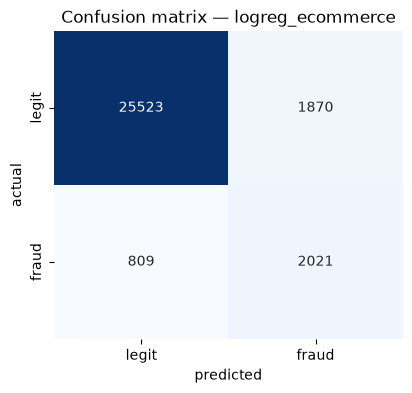

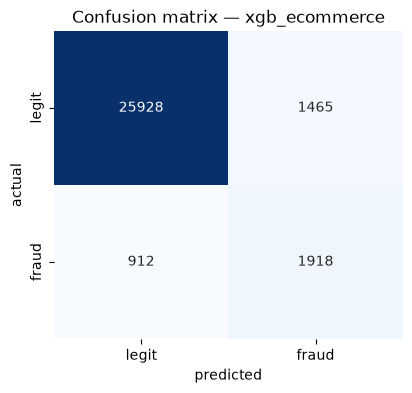

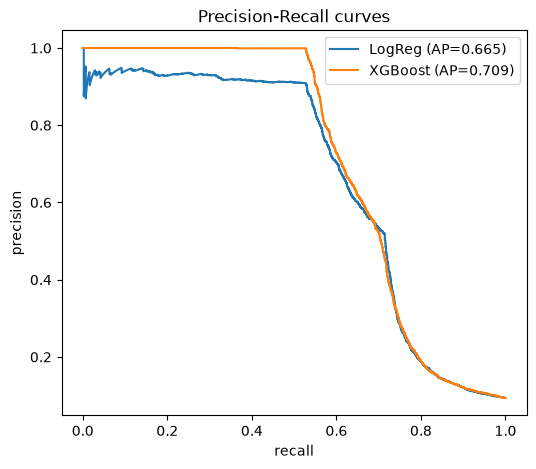

,auc_pr,roc_auc,f1,precision,recall
model,,,,,
LogReg (e-commerce),0.6651,0.8375,0.6014,0.5194,0.7141
XGBoost (e-commerce),0.7087,0.8404,0.6174,0.5670,0.6777


In [5]:
evaluation.plot_confusion(logreg, X_test, y_test, "logreg_ecommerce")
evaluation.plot_confusion(xgb, X_test, y_test, "xgb_ecommerce")
evaluation.plot_pr_curve(
    {"LogReg": logreg, "XGBoost": xgb}, X_test, y_test, name="pr_ecommerce"
)
plt.show()
evaluation.metrics_table(results)

## 3. Bank dataset (`creditcard`)

Same workflow; this dataset is extremely imbalanced (~0.17% fraud).

In [6]:
target_cc = "Class"
Xtr_c, Xte_c, ytr_c, yte_c = transform.stratified_split(cc, target_cc)
num_c, cat_c = transform.split_feature_types(cc, target_cc)
pre_c = transform.build_preprocessor(num_c, cat_c)

logreg_c = modeling.build_logreg_pipeline(pre_c, use_smote=True).fit(Xtr_c, ytr_c)
xgb_c = modeling.build_xgb_pipeline(pre_c, ytr_c, use_smote=False).fit(Xtr_c, ytr_c)

results_cc = [
    evaluation.evaluate(logreg_c, Xte_c, yte_c, "LogReg (creditcard)"),
    evaluation.evaluate(xgb_c, Xte_c, yte_c, "XGBoost (creditcard)"),
]


=== LogReg (creditcard) ===
    auc_pr: 0.6750
   roc_auc: 0.9626
        f1: 0.1000
 precision: 0.0530
    recall: 0.8737
              precision    recall  f1-score   support

           0     0.9998    0.9738    0.9866     56651
           1     0.0530    0.8737    0.1000        95

    accuracy                         0.9737     56746
   macro avg     0.5264    0.9238    0.5433     56746
weighted avg     0.9982    0.9737    0.9852     56746




=== XGBoost (creditcard) ===
    auc_pr: 0.8287
   roc_auc: 0.9773
        f1: 0.8671
 precision: 0.9615
    recall: 0.7895
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56651
           1     0.9615    0.7895    0.8671        95

    accuracy                         0.9996     56746
   macro avg     0.9806    0.8947    0.9334     56746
weighted avg     0.9996    0.9996    0.9996     56746



Saved -> reports/figures/confusion_logreg_creditcard.png


Saved -> reports/figures/confusion_xgb_creditcard.png


Saved -> reports/figures/pr_creditcard.png


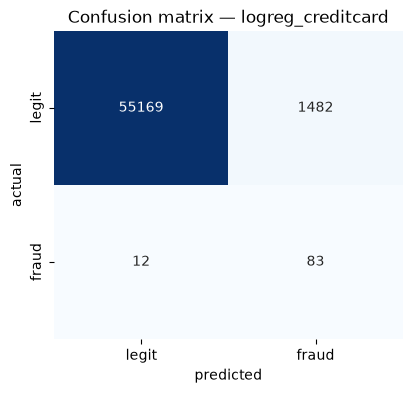

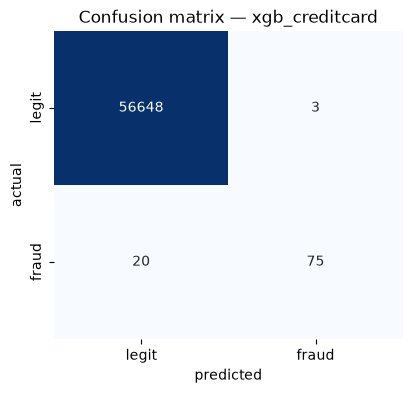

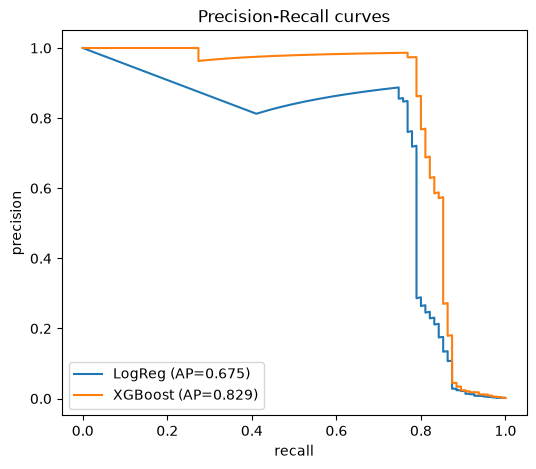

,auc_pr,roc_auc,f1,precision,recall
model,,,,,
LogReg (creditcard),0.6750,0.9626,0.1000,0.0530,0.8737
XGBoost (creditcard),0.8287,0.9773,0.8671,0.9615,0.7895


In [7]:
evaluation.plot_confusion(logreg_c, Xte_c, yte_c, "logreg_creditcard")
evaluation.plot_confusion(xgb_c, Xte_c, yte_c, "xgb_creditcard")
evaluation.plot_pr_curve(
    {"LogReg": logreg_c, "XGBoost": xgb_c}, Xte_c, yte_c, name="pr_creditcard"
)
plt.show()
evaluation.metrics_table(results_cc)

## 4. Save the best models

In [8]:
import joblib

models_dir = config.PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)
joblib.dump(xgb, models_dir / "xgb_ecommerce.joblib")
joblib.dump(xgb_c, models_dir / "xgb_creditcard.joblib")

# Combined comparison across both datasets.
evaluation.metrics_table(results + results_cc)

,auc_pr,roc_auc,f1,precision,recall
model,,,,,
LogReg (e-commerce),0.6651,0.8375,0.6014,0.5194,0.7141
XGBoost (e-commerce),0.7087,0.8404,0.6174,0.5670,0.6777
LogReg (creditcard),0.6750,0.9626,0.1000,0.0530,0.8737
XGBoost (creditcard),0.8287,0.9773,0.8671,0.9615,0.7895
